In [1]:
!pip install textstat -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.3 MB/s eta 0:00:0000:01


In [2]:
import textstat
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Sample Texts

In [3]:
texts = [
    """The cat sat on the mat. The dog ran in the park.
    The sun is big and bright. Birds fly in the sky.
    Children love to play outside. The flowers are pretty and colorful.
    Milk is good for your health. Always brush your teeth before bed.""",

    """Scientists have discovered a new species of deep-sea fish
    in the Pacific Ocean. The creature, found at depths exceeding
    3000 meters, displays remarkable bioluminescent properties.
    Researchers from the Marine Biology Institute conducted the study
    over a period of two years using advanced underwater drones.""",

    """The epistemological implications of quantum entanglement suggest
    a fundamental reconceptualization of classical deterministic frameworks.
    Subsequent empirical investigations corroborate the hypothesis that
    non-locality phenomena transcend conventional spatiotemporal constraints.
    The methodological paradigm necessitates a rigorous mathematical
    formalization of probabilistic wave function collapse mechanisms."""
]

levels = ["Simple", "Medium", "Complex"]
print(f"✅ {len(texts)} texts loaded")
print(f"📄 Levels: {levels}")

✅ 3 texts loaded
📄 Levels: ['Simple', 'Medium', 'Complex']


## Calculate All Stats

In [4]:
print("=" * 50)
print("      CALCULATING TEXT STATISTICS")
print("=" * 50)

records = []

for i, text in enumerate(texts):
    stats = {
        "level"               : levels[i],
        "word_count"          : textstat.lexicon_count(text, removepunct=True),
        "sentence_count"      : textstat.sentence_count(text),
        "syllable_count"      : textstat.syllable_count(text),
        "difficult_words"     : textstat.difficult_words(text),
        "avg_words_per_sent"  : round(textstat.avg_sentence_length(text), 2),
        "flesch_reading_ease" : round(textstat.flesch_reading_ease(text), 2),
        "flesch_kincaid_grade": round(textstat.flesch_kincaid_grade(text), 2),
        "gunning_fog"         : round(textstat.gunning_fog(text), 2),
        "smog_index"          : round(textstat.smog_index(text), 2),
        "ari_score"           : round(textstat.automated_readability_index(text), 2)
    }
    records.append(stats)

    print(f"\n📄 Text {i+1}: {levels[i]}")
    print(f"   Word Count          : {stats['word_count']}")
    print(f"   Sentence Count      : {stats['sentence_count']}")
    print(f"   Syllable Count      : {stats['syllable_count']}")
    print(f"   Difficult Words     : {stats['difficult_words']}")
    print(f"   Avg Words/Sentence  : {stats['avg_words_per_sent']}")
    print(f"   Flesch Reading Ease : {stats['flesch_reading_ease']}")
    print(f"   FK Grade Level      : {stats['flesch_kincaid_grade']}")
    print(f"   Gunning Fog         : {stats['gunning_fog']}")
    print(f"   SMOG Index          : {stats['smog_index']}")
    print(f"   ARI Score           : {stats['ari_score']}")

df_stats = pd.DataFrame(records)
print("\n✅ All stats calculated!")

      CALCULATING TEXT STATISTICS

📄 Text 1: Simple
   Word Count          : 46
   Sentence Count      : 8
   Syllable Count      : 54
   Difficult Words     : 2
   Avg Words/Sentence  : 5.75
   Flesch Reading Ease : 101.69
   FK Grade Level      : 0.5
   Gunning Fog         : 3.17
   SMOG Index          : 5.15
   ARI Score           : 0.49

📄 Text 2: Medium
   Word Count          : 44
   Sentence Count      : 3
   Syllable Count      : 86
   Difficult Words     : 20
   Avg Words/Sentence  : 14.67
   Flesch Reading Ease : 26.59
   FK Grade Level      : 13.19
   Gunning Fog         : 17.68
   SMOG Index          : 15.02
   ARI Score           : 14.06

📄 Text 3: Complex
   Word Count          : 41
   Sentence Count      : 3
   Syllable Count      : 127
   Difficult Words     : 31
   Avg Words/Sentence  : 13.67
   Flesch Reading Ease : -69.09
   FK Grade Level      : 26.29
   Gunning Fog         : 28.88
   SMOG Index          : 19.29
   ARI Score           : 27.91

✅ All stats calculated!

## Stats DataFrame

In [5]:
print("=" * 50)
print("         FULL STATISTICS TABLE")
print("=" * 50)
display(df_stats)

         FULL STATISTICS TABLE


,level,word_count,sentence_count,syllable_count,difficult_words,avg_words_per_sent,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,smog_index,ari_score
0,Simple,46,8,54,2,5.75,101.69,0.50,3.17,5.15,0.49
1,Medium,44,3,86,20,14.67,26.59,13.19,17.68,15.02,14.06
2,Complex,41,3,127,31,13.67,-69.09,26.29,28.88,19.29,27.91


## Flesch Reading Ease Bar Chart

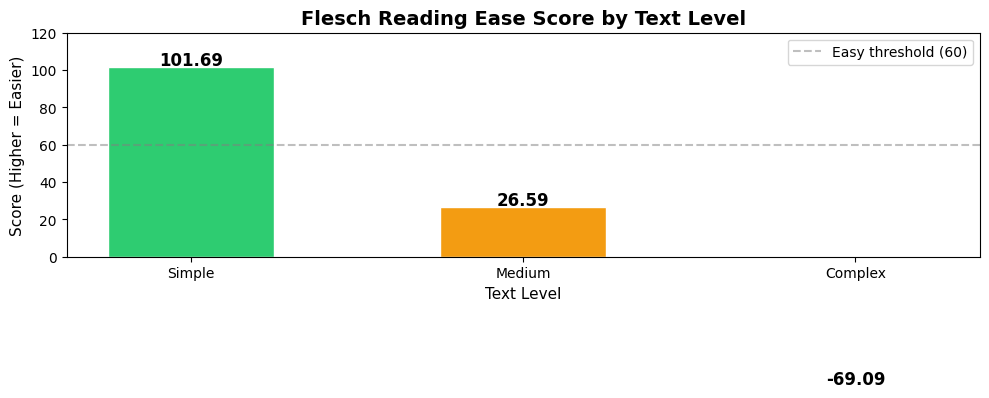

📌 Score Guide: 90-100=Very Easy | 60-70=Standard | 0-30=Very Difficult


In [6]:
colors = ["#2ECC71", "#F39C12", "#E74C3C"]

plt.figure(figsize=(10, 5))
bars = plt.bar(df_stats["level"],
               df_stats["flesch_reading_ease"],
               color=colors, width=0.5, edgecolor="white")

for bar, val in zip(bars, df_stats["flesch_reading_ease"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{val}", ha="center", fontsize=12, fontweight="bold")

plt.title("Flesch Reading Ease Score by Text Level",
          fontsize=14, fontweight="bold")
plt.xlabel("Text Level", fontsize=11)
plt.ylabel("Score (Higher = Easier)", fontsize=11)
plt.ylim(0, 120)
plt.axhline(y=60, color="gray", linestyle="--", alpha=0.5, label="Easy threshold (60)")
plt.legend()
plt.tight_layout()
plt.show()

print("📌 Score Guide: 90-100=Very Easy | 60-70=Standard | 0-30=Very Difficult")

## Grade Level Comparison

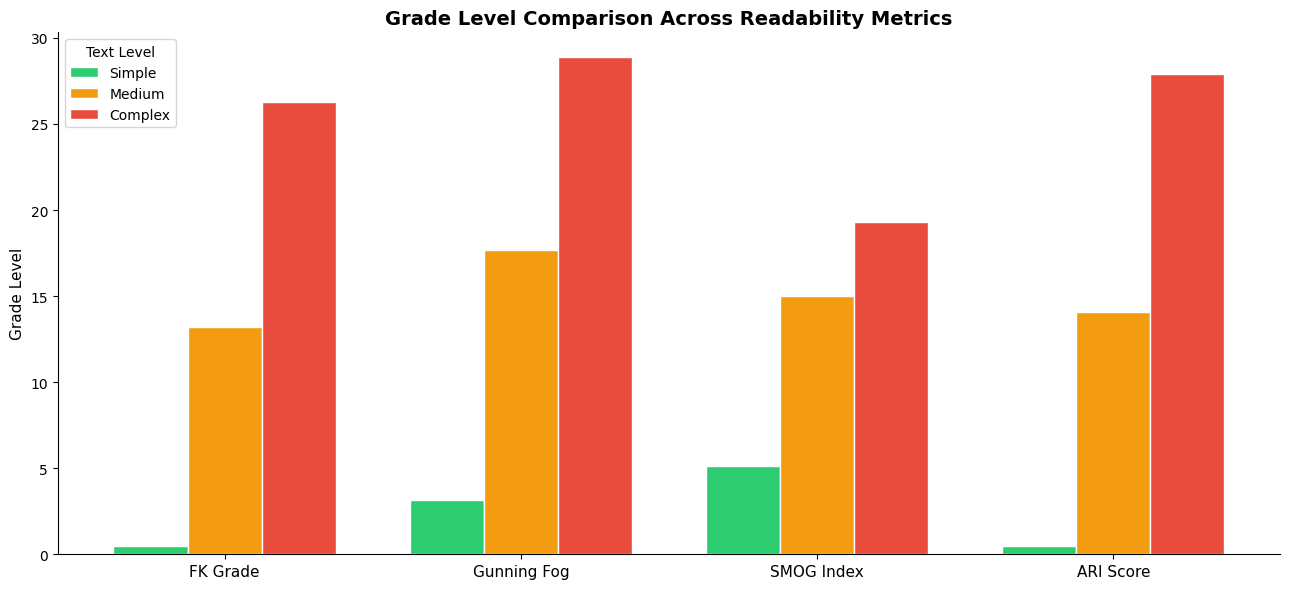

In [7]:
grade_metrics = ["flesch_kincaid_grade", "gunning_fog", "smog_index", "ari_score"]
grade_labels  = ["FK Grade", "Gunning Fog", "SMOG Index", "ARI Score"]

x = np.arange(len(grade_labels))
width = 0.25
colors = ["#2ECC71", "#F39C12", "#E74C3C"]

fig, ax = plt.subplots(figsize=(13, 6))

for i, (level, color) in enumerate(zip(levels, colors)):
    values = [df_stats.loc[i, m] for m in grade_metrics]
    bars = ax.bar(x + i * width, values, width,
                  label=level, color=color, edgecolor="white")

ax.set_title("Grade Level Comparison Across Readability Metrics",
             fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(grade_labels, fontsize=11)
ax.set_ylabel("Grade Level", fontsize=11)
ax.legend(title="Text Level")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

##  Radar Chart ⭐

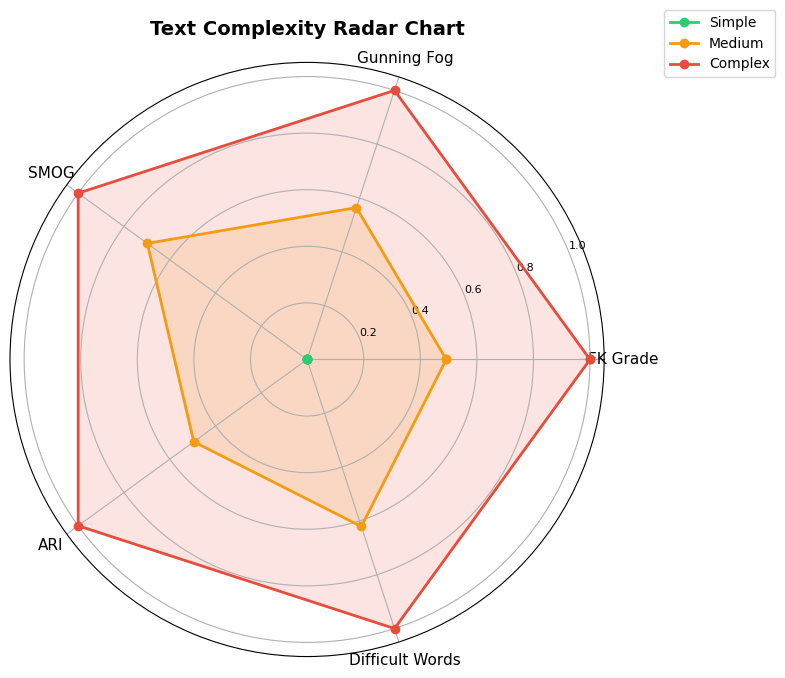

In [8]:
# Metrics for radar
radar_metrics = ["flesch_kincaid_grade", "gunning_fog",
                 "smog_index", "ari_score", "difficult_words"]
radar_labels  = ["FK Grade", "Gunning Fog", "SMOG", "ARI", "Difficult Words"]

# Normalize values 0 to 1
df_norm = df_stats[radar_metrics].copy()
df_norm = (df_norm - df_norm.min()) / (df_norm.max() - df_norm.min() + 1e-9)

N = len(radar_labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = ["#2ECC71", "#F39C12", "#E74C3C"]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (level, color) in enumerate(zip(levels, colors)):
    values = df_norm.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, color=color, label=level)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
ax.set_title("Text Complexity Radar Chart",
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## Difficult Words Analysis

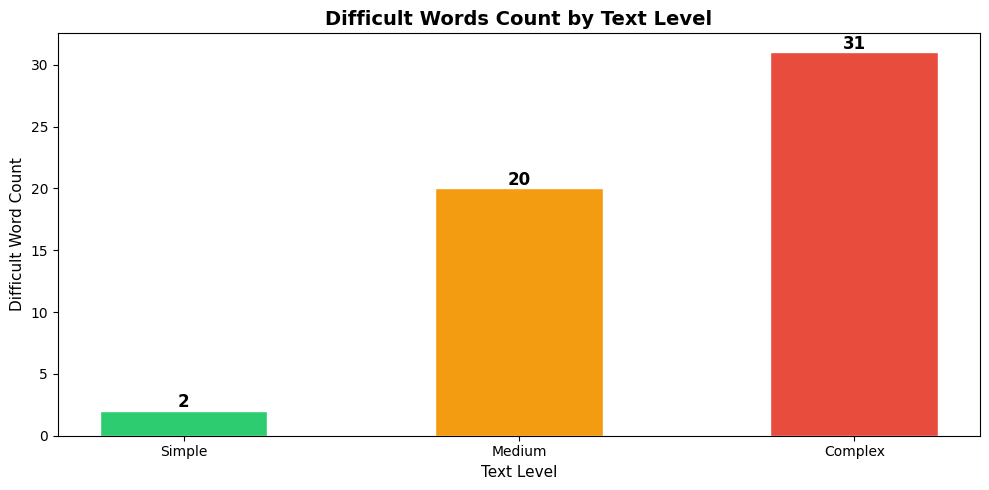

In [9]:
plt.figure(figsize=(10, 5))
bars = plt.bar(df_stats["level"],
               df_stats["difficult_words"],
               color=["#2ECC71", "#F39C12", "#E74C3C"],
               width=0.5, edgecolor="white")

for bar, val in zip(bars, df_stats["difficult_words"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(val), ha="center",
             fontsize=12, fontweight="bold")

plt.title("Difficult Words Count by Text Level",
          fontsize=14, fontweight="bold")
plt.xlabel("Text Level", fontsize=11)
plt.ylabel("Difficult Word Count", fontsize=11)
plt.tight_layout()
plt.show()

## Reusable Function

In [10]:
def get_text_stats(text: str) -> dict:
    """
    Input  : raw text string
    Output : dict of all readability + complexity scores
    """
    return {
        "word_count"          : textstat.lexicon_count(text, removepunct=True),
        "sentence_count"      : textstat.sentence_count(text),
        "syllable_count"      : textstat.syllable_count(text),
        "difficult_words"     : textstat.difficult_words(text),
        "avg_words_per_sent"  : round(textstat.avg_sentence_length(text), 2),
        "flesch_reading_ease" : round(textstat.flesch_reading_ease(text), 2),
        "flesch_kincaid_grade": round(textstat.flesch_kincaid_grade(text), 2),
        "gunning_fog"         : round(textstat.gunning_fog(text), 2),
        "smog_index"          : round(textstat.smog_index(text), 2),
        "ari_score"           : round(textstat.automated_readability_index(text), 2)
    }

# Test
sample = "The quick brown fox jumps over the lazy dog. Simple text is easy to read."
result = get_text_stats(sample)
print("Test Results:")
for key, val in result.items():
    print(f"  {key:<25} : {val}")

Test Results:
  word_count                : 15
  sentence_count            : 2
  syllable_count            : 19
  difficult_words           : 0
  avg_words_per_sent        : 7.5
  flesch_reading_ease       : 92.06
  flesch_kincaid_grade      : 2.28
  gunning_fog               : 3.0
  smog_index                : 3.13
  ari_score                 : 0.85


## SUMMARY

In [11]:
print("=" * 50)
print("  Notebook 4 Complete: Text Statistics")
print("=" * 50)
print(f"  Texts analyzed       : {len(texts)}")
print(f"  Metrics calculated   : 10 per text")
print(f"  Easiest text         : {df_stats.loc[df_stats['flesch_reading_ease'].idxmax(), 'level']}")
print(f"  Hardest text         : {df_stats.loc[df_stats['flesch_reading_ease'].idxmin(), 'level']}")
print(f"  Highest grade level  : {df_stats['flesch_kincaid_grade'].max()}")
print()
print("  ✅ get_text_stats() ready for utils/")
print("  ✅ All 4 notebooks complete!")
print("  ✅ Ready to build app.py")

  Notebook 4 Complete: Text Statistics
  Texts analyzed       : 3
  Metrics calculated   : 10 per text
  Easiest text         : Simple
  Hardest text         : Complex
  Highest grade level  : 26.29

  ✅ get_text_stats() ready for utils/
  ✅ All 4 notebooks complete!
  ✅ Ready to build app.py
